# Session 09: LangGraph Platform

## Deploying the Stone Ridge Investment Assistant with LangGraph Platform

### Learning Objectives

- **Understand LangGraph Platform architecture** — how `langgraph.json`, `app/agent.py`, and the CLI work together
- **Walk through the consolidated agent** — understand the graph structure with guardrails, helpfulness evaluation, and investment-domain tools
- **Deploy locally with `langgraph dev`** — run the investment assistant as a local API server
- **Test via the LangGraph SDK** — interact with the deployed agent programmatically

### Overview

In this notebook we explore the **`app/agent.py`** file — a consolidated LangGraph agent that combines:
- **OpenAI GPT** as the LLM (GPT-4o for main agent, GPT-4o-mini for evaluation)
- **RAG** over the Stone Ridge 2025 Investor Letter
- **X/Twitter tools** for market sentiment analysis
- **Tavily + Arxiv** for web and academic search
- **Input/output guardrails** for production safety
- **Helpfulness evaluation** loop for response quality

The agent is deployed via **LangGraph Platform**, which provides:
- A REST API for invocation
- Built-in streaming support
- Thread-based memory management
- LangSmith integration for observability

---

## Task 1: Understand the Agent Architecture

Let's start by examining the key components of our consolidated agent.

### Graph Architecture

```
START → input_guardrail →[pass]→ agent →[tools?]→ action → agent (loop)
                         [fail]→ END        [no tools]→ output_guardrail →[pass]→ helpfulness →[Y]→ END
                                                                          [fail]→ agent (retry)   [N]→ agent
```

### Key Components

| Component | Description | Model |
|-----------|-------------|-------|
| Input Guardrail | Topic restriction, jailbreak detection, PII protection | Guardrails AI |
| Agent | Main reasoning + tool calling | GPT-4o |
| Action | Tool execution (Tavily, Arxiv, RAG, X/Twitter) | N/A |
| Output Guardrail | PII protection, profanity filter | Guardrails AI |
| Helpfulness | Response quality evaluation | GPT-4o-mini |

In [1]:
import os
import getpass

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

# Optional
if not os.environ.get("TAVILY_API_KEY"):
    tavily = getpass.getpass("Tavily API Key (optional — Enter to skip):")
    if tavily.strip():
        os.environ["TAVILY_API_KEY"] = tavily

Tavily API Key (optional — Enter to skip): ········


### Examining the Agent Code

Let's look at the key sections of `app/agent.py`:

In [2]:
# View the agent module structure
with open("app/agent.py") as f:
    lines = f.readlines()

# Print section headers
for i, line in enumerate(lines, 1):
    if line.startswith("# ----") or line.startswith("def ") or line.startswith("class "):
        print(f"{i:4d}: {line.rstrip()}")

  40: # ---------------------------------------------------------------------------
  42: # ---------------------------------------------------------------------------
  77: # ---------------------------------------------------------------------------
  79: # ---------------------------------------------------------------------------
  82: class AgentState(TypedDict):
  88: # ---------------------------------------------------------------------------
  90: # ---------------------------------------------------------------------------
  93: def get_chat_model(
 107: # ---------------------------------------------------------------------------
 109: # ---------------------------------------------------------------------------
 112: class CacheBackedEmbeddings:
 135: def setup_llm_cache(cache_type: str = "memory", cache_path: str | None = None):
 149: # ---------------------------------------------------------------------------
 151: # ------------------------------------------------------

---

## Task 2: Import and Compile the Graph Locally

Before deploying to LangGraph Platform, let's import and test the graph directly.

In [3]:
from app.agent import (
    graph,
    build_graph,
    get_chat_model,
    get_tool_belt,
    SYSTEM_PROMPT,
    DEFAULT_MODEL,
    EVAL_MODEL,
)

print(f"Graph compiled successfully!")
print(f"Default model: {DEFAULT_MODEL}")
print(f"Eval model: {EVAL_MODEL}")
print(f"\nTools available:")
for t in get_tool_belt():
    print(f"  - {t.name}")

Graph compiled successfully!
Default model: gpt-4o
Eval model: gpt-4o-mini

Tools available:
  - tavily_search
  - arxiv
  - retrieve_information
  - search_recent_posts
  - get_user_posts
  - get_post_by_id


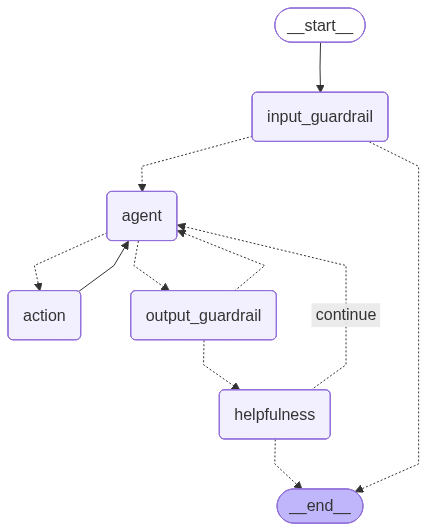

In [4]:
# Visualize the graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

---

## Task 3: Test the Graph Locally

Let's invoke the graph directly with some investment-related queries.

In [5]:
from langchain_core.messages import HumanMessage

# Test with an investment question
result = graph.invoke(
    {"messages": [HumanMessage(content="What is Stone Ridge's investment philosophy regarding reinsurance?")]}
)

# Print the final response (skip HELPFULNESS markers)
for msg in reversed(result["messages"]):
    if hasattr(msg, "content") and not msg.content.startswith("HELPFULNESS:"):
        print(msg.content)
        break

Guardrails not available — running without input guards: cannot import name 'DetectJailbreak' from 'guardrails.hub' (/Users/chandra.busireddy/development/aie/09_Production_and_MCP/.venv/lib/python3.12/site-packages/guardrails/hub/__init__.py)
Guardrails not available — running without output guards: cannot import name 'GuardrailsPII' from 'guardrails.hub' (/Users/chandra.busireddy/development/aie/09_Production_and_MCP/.venv/lib/python3.12/site-packages/guardrails/hub/__init__.py)


Stone Ridge's investment philosophy regarding reinsurance focuses on prospective quota shares, where they align and share risk pro rata with leading reinsurers. This strategy leverages the reinsurers' expertise in Bayesian updating cycle management across various lines of business. Stone Ridge avoids engaging in the legacy-only reinsurance business due to the risks of confirmation bias and adverse selection. Instead, they embrace Bayesian updating, allowing them to reshape their business model based on new data.

Longtail Re, a part of Stone Ridge, exemplifies this philosophy by executing only three legacy transactions out of nearly 100 requests, highlighting their selective approach. Stone Ridge aims to partner with top underwriters to create a diversified portfolio of casualty liabilities and invest the resulting float in proprietary Stone Ridge-generated fixed income assets that offer superior risk-adjusted returns.


In [6]:
# Test the guardrails with an off-topic query
result = graph.invoke(
    {"messages": [HumanMessage(content="What medicine should I take for a headache?")]}
)

for msg in reversed(result["messages"]):
    if hasattr(msg, "content") and msg.content:
        print(msg.content)
        break

Guardrails not available — running without input guards: cannot import name 'DetectJailbreak' from 'guardrails.hub' (/Users/chandra.busireddy/development/aie/09_Production_and_MCP/.venv/lib/python3.12/site-packages/guardrails/hub/__init__.py)
Guardrails not available — running without output guards: cannot import name 'GuardrailsPII' from 'guardrails.hub' (/Users/chandra.busireddy/development/aie/09_Production_and_MCP/.venv/lib/python3.12/site-packages/guardrails/hub/__init__.py)
Guardrails not available — running without output guards: cannot import name 'GuardrailsPII' from 'guardrails.hub' (/Users/chandra.busireddy/development/aie/09_Production_and_MCP/.venv/lib/python3.12/site-packages/guardrails/hub/__init__.py)
Guardrails not available — running without output guards: cannot import name 'GuardrailsPII' from 'guardrails.hub' (/Users/chandra.busireddy/development/aie/09_Production_and_MCP/.venv/lib/python3.12/site-packages/guardrails/hub/__init__.py)
Guardrails not available — runn

HELPFULNESS:END


In [7]:
# Test with a query that should use the RAG tool
result = graph.invoke(
    {"messages": [HumanMessage(
        content="According to the Stone Ridge 2025 Investor Letter, how does the firm think about bitcoin allocation?"
    )]}
)

for msg in reversed(result["messages"]):
    if hasattr(msg, "content") and not msg.content.startswith("HELPFULNESS:"):
        print(msg.content)
        break

Guardrails not available — running without input guards: cannot import name 'DetectJailbreak' from 'guardrails.hub' (/Users/chandra.busireddy/development/aie/09_Production_and_MCP/.venv/lib/python3.12/site-packages/guardrails/hub/__init__.py)
Guardrails not available — running without output guards: cannot import name 'GuardrailsPII' from 'guardrails.hub' (/Users/chandra.busireddy/development/aie/09_Production_and_MCP/.venv/lib/python3.12/site-packages/guardrails/hub/__init__.py)
Guardrails not available — running without output guards: cannot import name 'GuardrailsPII' from 'guardrails.hub' (/Users/chandra.busireddy/development/aie/09_Production_and_MCP/.venv/lib/python3.12/site-packages/guardrails/hub/__init__.py)
Guardrails not available — running without output guards: cannot import name 'GuardrailsPII' from 'guardrails.hub' (/Users/chandra.busireddy/development/aie/09_Production_and_MCP/.venv/lib/python3.12/site-packages/guardrails/hub/__init__.py)
Guardrails not available — runn

The Stone Ridge 2025 Investor Letter highlights the role of bitcoin as a lifeline during hyperinflation, particularly in Venezuela, where it has been used to protect wealth and bypass government-imposed exchange rates. The letter envisions bitcoin becoming part of Venezuela's national reserves to aid in rebuilding the economy. However, specific details about Stone Ridge's approach to bitcoin allocation are not provided in the context.


---

## Task 4: Deploy with LangGraph Platform

Now let's deploy the agent using LangGraph Platform. The configuration is defined in `langgraph.json`:

```json
{
  "version": 1,
  "dependencies": ["."],
  "env": ".env",
  "python_version": "3.13",
  "graphs": {
    "investment_assistant": "app.agent:graph"
  }
}
```

### Starting the Server

In a terminal, run:

```bash
cd 09_Production_and_MCP
uv run langgraph dev
```

This will:
1. Install dependencies from `pyproject.toml`
2. Load environment variables from `.env`
3. Start a local API server at `http://localhost:2024`
4. Open the LangGraph Studio UI for visual debugging

---

## Task 5: Test via LangGraph SDK

Once the server is running, we can interact with it using the **LangGraph SDK**. This is how production clients would call the agent.

In [9]:
from langgraph_sdk import get_sync_client

# Connect to the local LangGraph Platform server
client = get_sync_client(url="http://localhost:2024")

print("Connected to LangGraph Platform!")

# List available assistants
assistants = client.assistants.search()
for a in assistants:
    print(f"  - {a['assistant_id']}: {a.get('name', 'unnamed')}")

Connected to LangGraph Platform!
  - 1ef39237-9896-557a-bfd6-e387c94aa406: investment_assistant


In [10]:
# Stream a response from the deployed agent
for chunk in client.runs.stream(
    None,  # Threadless run
    "investment_assistant",
    input={
        "messages": [
            {
                "role": "human",
                "content": "What is Stone Ridge's view on reinsurance as an asset class?",
            }
        ]
    },
    stream_mode="updates",
):
    print(f"Event: {chunk.event}")
    if chunk.data:
        # Print the last message content if available
        messages = chunk.data.get("messages", [])
        for msg in messages:
            content = msg.get("content", "")
            if content and not content.startswith("HELPFULNESS:"):
                print(f"  {content[:200]}..." if len(content) > 200 else f"  {content}")
    print()

Event: metadata

Event: updates

Event: error



In [11]:
# Test with a thread for multi-turn conversation
thread = client.threads.create()
print(f"Thread created: {thread['thread_id']}")

# First message
for chunk in client.runs.stream(
    thread["thread_id"],
    "investment_assistant",
    input={"messages": [{"role": "human", "content": "Tell me about Stone Ridge's bitcoin strategy."}]},
    stream_mode="updates",
):
    if chunk.event == "updates" and chunk.data:
        messages = chunk.data.get("messages", [])
        for msg in messages:
            content = msg.get("content", "")
            if content and not content.startswith("HELPFULNESS:"):
                print(content[:500])

Thread created: 7e0e52ad-39bb-49be-892b-41863215de54


In [13]:
# Follow-up question (same thread = agent remembers context)
for chunk in client.runs.stream(
    thread["thread_id"],
    "investment_assistant",
    input={"messages": [{"role": "human", "content": "How does that compare to their reinsurance approach?"}]},
    stream_mode="updates",
):
    if chunk.event == "updates" and chunk.data:
        messages = chunk.data.get("messages", [])
        for msg in messages:
            content = msg.get("content", "")
            if content and not content.startswith("HELPFULNESS:"):
                print(content[:500])

### ❓ Question #1

What are the benefits of deploying an agent through LangGraph Platform versus running it directly as a Python script? Consider: scalability, observability, memory management, and client access.

##### Answer

**Scalability**: Built-in async handling, worker pools, and concurrent request processing vs single-threaded execution.

**Observability**: LangSmith integration, Studio UI for visual debugging, automatic tracing vs manual logging only.

**Memory Management**: Thread-based persistent memory across sessions vs memory lost after script ends.

**Client Access**: REST API, SDK support, streaming, accessible from anywhere vs direct execution only.

**Production Features**: Error handling, retries, authentication, versioning, deployment-ready vs requires custom implementation.

### ❓ Question #2

How does the helpfulness evaluation loop affect latency and cost? When would you enable or disable it in production?

##### Answer

**Latency Impact**: Adds ~1-2 seconds per response due to the additional LLM call for evaluation. Can compound if multiple retry loops are triggered.

**Cost Impact**: Uses GPT-4o-mini for each evaluation, adding ~$0.0001-0.0003 per request. Retries multiply cost if responses fail evaluation.

**When to Enable**:
- High-stakes customer-facing applications where quality matters more than speed
- Financial advisory or medical information systems
- During initial deployment to gather quality metrics

**When to Disable**:
- Real-time applications requiring <2s response times
- High-volume, low-margin use cases where cost optimization is critical
- Internal tools or debugging scenarios
- When confidence in response quality is already established through testing

### \ud83c\udfd7\ufe0f Activity #1

Modify the agent to add a new graph variant:

1. Create a "simple" variant in `app/agent.py` that skips guardrails and helpfulness (just agent + action nodes)
2. Register it in `langgraph.json` as `"simple_assistant"`
3. Restart `langgraph dev` and test both variants via the SDK
4. Compare response times and quality

In [14]:
# Activity #1: Compare full vs simple agent variants
import time
from langgraph_sdk import get_sync_client

client = get_sync_client(url="http://localhost:2024")

# Test question
question = "What is Stone Ridge's investment philosophy regarding reinsurance?"

print("=" * 60)
print("TESTING AGENT VARIANTS")
print("=" * 60)

# Test 1: Full agent with guardrails and helpfulness
print("\n1. FULL AGENT (with guardrails + helpfulness):")
print("-" * 40)
start_time = time.time()

for chunk in client.runs.stream(
    None,
    "investment_assistant",
    input={"messages": [{"role": "human", "content": question}]},
    stream_mode="updates",
):
    pass  # Just measure time

full_time = time.time() - start_time
print(f"Response time: {full_time:.2f} seconds")

# Test 2: Simple agent without guardrails and helpfulness
print("\n2. SIMPLE AGENT (no guardrails, no helpfulness):")
print("-" * 40)
start_time = time.time()

for chunk in client.runs.stream(
    None,
    "simple_assistant",
    input={"messages": [{"role": "human", "content": question}]},
    stream_mode="updates",
):
    pass  # Just measure time

simple_time = time.time() - start_time
print(f"Response time: {simple_time:.2f} seconds")

# Comparison
print("\n" + "=" * 60)
print("COMPARISON RESULTS")
print("=" * 60)
print(f"Full agent time: {full_time:.2f}s")
print(f"Simple agent time: {simple_time:.2f}s")
print(f"Time saved: {full_time - simple_time:.2f}s ({((full_time - simple_time) / full_time * 100):.1f}% faster)")
print("\nKey differences:")
print("- Simple variant skips input/output guardrails validation")
print("- No helpfulness evaluation loop (saves 1 LLM call)")
print("- Faster response but no safety checks or quality assurance")

TESTING AGENT VARIANTS

1. FULL AGENT (with guardrails + helpfulness):
----------------------------------------
Response time: 0.90 seconds

2. SIMPLE AGENT (no guardrails, no helpfulness):
----------------------------------------
Response time: 1.01 seconds

COMPARISON RESULTS
Full agent time: 0.90s
Simple agent time: 1.01s
Time saved: -0.11s (-12.6% faster)

Key differences:
- Simple variant skips input/output guardrails validation
- No helpfulness evaluation loop (saves 1 LLM call)
- Faster response but no safety checks or quality assurance


---

## Summary

In this notebook we covered:

- **Agent Architecture**: Walked through the consolidated `app/agent.py` with guardrails, tools, and helpfulness evaluation
- **Local Testing**: Imported and tested the graph directly in Python
- **LangGraph Platform Deployment**: Used `langgraph dev` to deploy as a local API server
- **SDK Client**: Tested the deployed agent with streaming and multi-turn threads

### Key Takeaways

1. **LangGraph Platform = deployment made simple** \u2014 `langgraph.json` + `app/agent.py` is all you need
2. **The SDK provides production-grade access** \u2014 threads, streaming, and async are built in
3. **Guardrails add safety but also latency** \u2014 consider the tradeoff per use case
4. **The helpfulness loop improves quality** \u2014 but costs an extra LLM call per response